# Activations, Forward Propagation & Loss 

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

### Table of Contents:

1. [Introduction](#intro)
2. [Section 1 — Non-Linearity ](#section1)
3. [Section 2 — Common Activation Functions](#section2)
4. [Section 3 — Forward Propagation](#section3)
5. [Section 4 - The Loss Function](#section4)
6. [Section 5 - Hands-on Lap](#section5)


### Learning Objectives Of This Notebook

-  Explain why non-linear activations are essential.
- Choose the correct activation for hidden and output layers.
- Describe forward propagation and select the right loss function for a task.



<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="intro"></a>
# Introduction



In the previous phase of the training, the focus was primarily on traditional machine learning techniques, including data preprocessing, supervised learning, model evaluation, and unsupervised learning. This notebook introduces the fundamental concepts behind **Neural Networks** and provides an initial look at how data flows through a network to produce predictions.

A neural network learns by transforming input data through a series of connected layers. Each neuron performs a weighted calculation using the input features, weights, and bias, followed by an **activation function** that introduces non-linearity into the network. This allows neural networks to learn more complex relationships that cannot be captured using linear operations alone.

This notebook focuses on understanding the first part of the neural network learning process: **forward propagation**. 

By the end of this notebook, the fundamental mechanics behind how a neural network transforms input data into predictions—and how those predictions are later evaluated during training—will be established.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section1"></a>
# Section 1 : Non-Linearity 



Before introducing activation functions, it is important to understand what a neuron does first. A neuron takes the input features, multiplies them by their corresponding weights, and calculates their sum:

$$
z = W \cdot X + b
$$

where (W) represents the weights, (X) represents the input features, and (b) is the bias. The result, (z), is a **linear output**.

 > <div style="text-align: center;"> <img src="beforeActivation.PNG" alt="how decks look " width="500" > </div>


However, learning linear relationships is not always enough. Real-world data often contains complex and non-linear patterns that cannot be represented using a straight line or a simple linear decision boundary.

This is where **activation functions** become important. An activation function is applied to the linear output of a neuron:

$$
a = f(W \cdot X + b)
$$

It introduces **non-linearity** into the network, allowing it to learn more complex relationships and patterns in the data.

Without activation functions, adding more layers would not make the network capable of learning more complex patterns. No matter how many layers are stacked together, a combination of linear operations still produces a linear result. Activation functions break this linearity, making it possible for deep neural networks to model complex, curved relationships.

In this sense, activation functions are one of the key components that make **deep learning** powerful.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section2"></a>
# Section 2 : Common Activation Functions

> Different activation functions serve different purposes in a neural network. The choice of activation function depends mainly on **where it is used in the network** and **what type of problem the model is trying to solve**.
>
--------

## 2.1 Sigmoid

**Visual Representation:**
 > <div style="text-align: center;"> <img src="sigmoid.PNG" alt="sigmoid graph " width="400" > </div>

**Formula:**
$$
f(x) = \frac{1}{1 + e^{-x}}
$$

**Output Range:** 
> ((0, 1))

**Where is it usually used?**
> Sigmoid is commonly used in the **output layer** for **binary classification** problems.

**When should it be used?**
> Use Sigmoid when the model needs to predict between **two possible classes**, such as:

* Yes / No
* Spam / Not Spam
* Positive / Negative
* 0 / 1

**Why is it used?**
> The output of the Sigmoid function can be interpreted as a **probability** between 0 and 1.

For example:


0.85 = 85% --> probability of belonging to the positive class


**What problem does it help solve?**
> It converts any numerical output from the network into a value between 0 and 1, making it suitable for predicting the probability of one class in a binary classification problem.


-----------


## 2.2 ReLU — Rectified Linear Unit

**Visual Representation:**
 > <div style="text-align: center;"> <img src="Relu-activation-function.PNG" alt="ReLU graph " width="400" > </div>

**Formula:**

$$
f(x) = \max(0, x)
$$

This means:

* If $(x > 0)$, the output is $x$.
* If $(x \leq 0)$, the output is $0$.

**Output Range:** ($0, +\infty$)

**Where is it usually used?**
ReLU is most commonly used in the **hidden layers** of a neural network.

**When should it be used?**
ReLU is generally the default choice for hidden layers, especially in deep neural networks.

**Why is it used?**
ReLU introduces non-linearity while remaining computationally simple. Unlike some other activation functions, positive values are passed through directly, which helps the network learn efficiently.

**What problem does it help solve?**
Functions such as Sigmoid and Tanh can suffer from the **vanishing gradient problem**, where gradients become very small during training. ReLU helps reduce this problem for positive input values, allowing deeper networks to train more effectively.



---

## 2.3 Softmax

**Visual Representation:**
 > <div style="text-align: center;"> <img src="softmax.PNG" alt="Softmax graph " width="400" > </div>


**Formula:**

For a set of outputs $(z_1, z_2, ..., z_n)$:

$$
\text{Softmax}(z_i) =
\frac{e^{z_i}}
{\sum_{j=1}^{n} e^{z_j}}
$$

**Output Range:** Each output is between $(0, 1)$, and all outputs sum to **1**.

**Where is it usually used?**
Softmax is usually used in the **output layer** for **multi-class classification**.

**When should it be used?**
Use Softmax when there are **more than two possible classes** and each input belongs to only one class.

For example:

* Classifying an image as a **cat, dog, or bird**
* Predicting the type of a flower
* Classifying handwritten digits from **0 to 9**

**Why is it used?**
Softmax converts the outputs of the network into a probability distribution across all possible classes.

For example:
| Class | Probability |
| ----- | ----------: |
| Cat   |        0.10 |
| Dog   |        0.75 |
| Bird  |        0.15 |

The probabilities sum to:

$
0.10 + 0.75 + 0.15 = 1
$

The class with the highest probability is usually selected as the prediction.

**What problem does it help solve?**
It allows the model to choose between multiple mutually exclusive classes while providing a probability for each possible class.

--------------

## 2.4 Tanh — Hyperbolic Tangent

**Visual Representation:**
> <div style="text-align: center;"> <img src="tanh.PNG" alt="tanh graph " width="400" > </div>

**Formula:**

$$
f(x) = \tanh(x)
$$

It can also be written as:

$$
f(x) =
\frac{e^x - e^{-x}}
{e^x + e^{-x}}
$$

**Output Range:** $(-1, 1)$

**Where is it usually used?**
Tanh can be used in **hidden layers**.

**When should it be used?**
It can be useful when having both positive and negative outputs is beneficial.

**Why is it used?**
Unlike Sigmoid, which produces outputs between 0 and 1, Tanh is **zero-centered**, meaning its outputs are centered around zero.
This can sometimes make optimization easier because the activations can move in both positive and negative directions.

**What problem does it help solve?**
Tanh provides a non-linear transformation while allowing negative, positive, and zero outputs. However, like Sigmoid, it can suffer from the **vanishing gradient problem**, particularly when the input values become very large or very small.

---

## 2.5 Choosing a suitable activation function

A simple guideline for choosing activation functions is:

| Network Layer / Task                              | Recommended Activation Function | Why?                                                         |
| ------------------------------------------------- | ------------------------------- | ------------------------------------------------------------ |
| **Hidden Layers**                                 | **ReLU**                        | Fast, simple, and effective for learning non-linear patterns |
| **Binary Classification Output**                  | **Sigmoid**                     | Produces a probability between 0 and 1                       |
| **Multi-Class Classification Output**             | **Softmax**                     | Produces probabilities across multiple classes that sum to 1 |
| **Regression Output**                             | **Linear / No Activation**      | Allows the model to predict continuous numerical values      |
| **Hidden Layers requiring zero-centered outputs** | **Tanh**                        | Produces values between -1 and 1                             |

### Key Takeaway

The activation function used in the **hidden layers** determines how the network learns complex patterns, while the activation function used in the **output layer** depends mainly on the type of prediction task.

> **A practical rule:** Use **ReLU** as the default for hidden layers, then choose the output activation based on the problem: **Sigmoid for binary classification, Softmax for multi-class classification, and Linear activation for regression.**


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section3"></a>
# Section 3 : Forward Propagation


**Forward propagation**, also called the **forward pass**, is the process through which a neural network takes an input and passes it forward through its layers to produce a prediction.

At this stage, the network is simply making its **current prediction** based on its existing weights and biases. It has not yet received any feedback about whether the prediction is correct or incorrect. The prediction will later be compared with the actual value during the training process, and the network can then use this feedback to update its weights through **backpropagation**.


**One Neuron (Logestic Regression)**
> <div style="text-align: center;"> <img src="Forward Propagation.jpg" alt="Summary visualization of forward propagation  " width="400" > </div>

> **Input → Weighted Sum → Activation Function → Prediction**
>
**Multi Layer**
> <div style="text-align: center;"> <img src="multi layers.png " alt="Summary visualization of forward propagation  " width="400" > </div>

>**Input → Weighted Sum → Activation Function → Next Layer → Prediction**
------

## 3.1 The Forward Propagation Process

The process follows these steps:

1. **Input enters the network**

   The input features are provided to the input layer.

2. **Calculate the weighted sum**

   Each neuron combines the inputs with its weights and bias:

   $$
   z = XW + b
   $$

3. **Apply an activation function**

   The linear output is passed through an activation function:

   $$
   a = f(z)
   $$

   This activated output becomes the input for the next layer.

4. **Repeat through the hidden layers**

   The same process is repeated in each layer:

   $$
   \text{Input} \rightarrow \text{Weighted Sum} \rightarrow \text{Activation}
   $$

5. **Produce the final prediction**

   The output layer applies the appropriate activation function depending on the problem. For example, a **Sigmoid** activation can produce a probability for binary classification.


-------------   




## 3.2 Conceptual Example

For a neural network with two hidden layers and one output layer, the forward pass can be represented as:

$
\text{Layer 1} = \text{ReLU}(XW_1 + b_1)
$

$
\text{Layer 2} = \text{ReLU}(\text{Layer 1}W_2 + b_2)
$

$
\text{Output} = \text{Sigmoid}(\text{Layer 2}W_3 + b_3)
$

The data continues moving in only one direction—from the **input layer**, through the **hidden layers**, and finally to the **output layer**.

----------

## 3.3 Implementation in Code

Conceptually, the same process can be written as:

```python
# First hidden layer
layer1 = ReLU(np.dot(X, W1) + b1)

# Second hidden layer
layer2 = ReLU(np.dot(layer1, W2) + b2)

# Output layer
output = sigmoid(np.dot(layer2, W3) + b3)
```

Each line follows the same pattern:

1. Perform the **dot product** between the input and the layer's weights.
2. Add the **bias**.
3. Apply the **activation function**.
4. Pass the resulting output to the next layer.

The final value, `output`, is the network's **prediction**.

> **Key idea:** Forward propagation is the first half of the training process. The network moves data forward to make a prediction. After that, the prediction is evaluated, and the network uses backpropagation to learn from its error and improve its weights.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section4"></a>
# Section 4 : The Loss Function

After the neural network completes **forward propagation**, it produces a prediction. However, at this point, the network does not yet know whether its prediction is correct.

The next step is to compare the predicted output with the **actual or true value**. This comparison is performed using a **loss function**.

In simple terms:

> **The loss function measures how wrong the model's prediction is.**

For example, suppose the true value is:

$$
y = 1
$$

and the neural network predicts:

$$
\hat{y} = 0.3
$$

The loss function measures the difference between these values and produces a number representing the model's error.

* **Low loss** → the prediction is closer to the true value.
* **High loss** → the prediction is further from the true value.

The main goal of training a neural network is therefore to **adjust the weights and biases to minimize the loss**.

---

## 4.2 Mathematical Representation

In general, the loss function can be represented as:

$$
L = L(y, \hat{y})
$$

where:

* $y$ = the actual or true value.
* $\hat{y}$ = the predicted value.
* $L$ = the calculated loss.

The exact mathematical formula depends on the type of machine learning problem being solved.

---

## 4.3 Common Loss Functions

| Task                           | Loss Function             | Mathematical Formula                                             | Why Is It Used?                                                                                                       |
| ------------------------------ | ------------------------- | ---------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **Regression**                 | Mean Squared Error (MSE)  | $$(\displaystyle MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2)$$ | Measures the squared difference between predicted and actual numerical values. Large errors receive a larger penalty. |
| **Binary Classification**      | Binary Cross-Entropy      | $$(\displaystyle L = -[y\log(\hat{y})+(1-y)\log(1-\hat{y})])$$       | Measures how well predicted probabilities match the true binary labels.                                               |
| **Multi-Class Classification** | Categorical Cross-Entropy | $$(\displaystyle L = -\sum_{i=1}^{C}y_i\log(\hat{y}_i))$$            | Measures how well the predicted probability distribution matches the correct class.                                   |

---


### 4.3.1. Mean Squared Error (MSE)


MSE is commonly used for **regression problems**, where the model predicts a continuous numerical value.

The formula is:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

The model calculates the difference between the actual and predicted value, squares the difference, and then calculates the average across all examples.

The error is squared, which means that **larger mistakes are penalized more heavily**.

For example:

$$
y = 10, \qquad \hat{y} = 8
$$

The squared error is:

$$
(10-8)^2 = 4
$$

---

### 4.3.2. Binary Cross-Entropy

Binary Cross-Entropy is commonly used for **binary classification**, where there are two possible classes, such as:

* 0 or 1
* Yes or No
* Positive or Negative

It is commonly paired with a **Sigmoid activation function** because Sigmoid produces an output between 0 and 1, representing the predicted probability.

The formula is:

$$
L = -[y\log(\hat{y})+(1-y)\log(1-\hat{y})]
$$

If the true label is 1, the loss becomes smaller when the predicted probability is closer to 1. If the true label is 0, the loss becomes smaller when the predicted probability is closer to 0.

Therefore, the model is rewarded for assigning a **high probability to the correct class** and penalized when it is confidently wrong.

---


### 4.3.3. Categorical Cross-Entropy

Categorical Cross-Entropy is used for **multi-class classification**, where the model must choose between multiple possible classes.

For example:

* Cat
* Dog
* Bird

It is commonly paired with the **Softmax activation function**, which produces a probability for each class.

The formula is:

$$
L = -\sum_{i=1}^{C}y_i\log(\hat{y}_i)
$$

where:

* $C$ is the total number of classes.
* $y_i$ represents the true value for class $i$.
* $\hat{y}_i$ represents the predicted probability for class $i4.

The loss becomes smaller when the model assigns a high probability to the correct class.

---

### 4.3.4 The Role of Loss in the Learning Process

The loss function is the bridge between **making a prediction** and **learning from that prediction**.

The overall process is:

$$
\text{Input}
\rightarrow
\text{Forward Propagation}
\rightarrow
\text{Prediction}
\rightarrow
\text{Calculate Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Update Weights}
$$

During training:

1. The network performs **forward propagation** and makes a prediction.
2. The loss function compares the prediction with the true value.
3. The calculated loss tells the network how wrong its current prediction is.
4. **Backpropagation** calculates how the weights contributed to this error.
5. An optimization algorithm updates the weights and biases.
6. The process is repeated many times.

Over time, the goal is:

$$
\boxed{\text{Minimize Loss} \Rightarrow \text{Improve Predictions}}
$$

> **Key Idea:** The neural network learns by making predictions, measuring how wrong they are using a loss function, and then adjusting its weights to reduce that loss in future predictions.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

<a id="section5"></a>
# Section 5 : Hands-on Lap - Activations & the Forward Pass


For this hands-on section, the **Heart Disease dataset** (`heart_2020_raw.csv`) is used as a practical example to demonstrate activation functions and forward propagation. This is a large dataset containing more than **300,000 samples** and multiple health-related features. The same dataset was previously used in **Project One**, where it was part of the cardiac disease monitoring system developed during the previous week.

Before using the data as input to the neural network, it needs to be prepared and converted into a numerical format that can be processed by the model. The preprocessing steps include:

1. **Loading the dataset** from the CSV file.
2. **Identifying and removing duplicate records** to avoid unnecessary repetition in the data.
3. **Encoding categorical features** into numerical values, since neural networks and other machine learning models require numerical input.
4. **Separating the target variable**, `HeartDisease`, from the input features for the later stages of the experiment.

After these preprocessing steps, the dataset is ready to be used for data splitting, scaling, and demonstrating the forward propagation process using real patient samples.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("heart_2020_raw.csv")
print("Shape:", df.shape)
df.head()

n_dupes = df.duplicated().sum()
df_clean = df.drop_duplicates().reset_index(drop=True)


binary_map = {"Yes": 1, "No": 0}
binary_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
               "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

df_clean["Sex"] = df_clean["Sex"].map({"Male": 1, "Female": 0})
df_clean["HeartDisease"] = df_clean["HeartDisease"].map(binary_map)

df_clean[binary_cols + ["Sex", "HeartDisease"]].head()

age_midpoints = {
    "18-24": 21, "25-29": 27, "30-34": 32, "35-39": 37, "40-44": 42,
    "45-49": 47, "50-54": 52, "55-59": 57, "60-64": 62, "65-69": 67,
    "70-74": 72, "75-79": 77, "80 or older": 82,
}
df_clean["AgeNumeric"] = df_clean["AgeCategory"].map(age_midpoints)

genhealth_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}
df_clean["GenHealthNumeric"] = df_clean["GenHealth"].map(genhealth_map)

df_clean[["AgeCategory", "AgeNumeric", "GenHealth", "GenHealthNumeric"]].head()

Shape: (319795, 18)


,AgeCategory,AgeNumeric,GenHealth,GenHealthNumeric
0,55-59,57,Very good,3
1,80 or older,82,Very good,3
2,65-69,67,Fair,1
3,75-79,77,Good,2
4,40-44,42,Very good,3


### Dropping the colums after we performed encoding

In [8]:
df_model = df_clean.drop(
    columns=["AgeCategory", "GenHealth"]
)

df_model = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301717 entries, 0 to 301716
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   HeartDisease                      301717 non-null  int64  
 1   BMI                               301717 non-null  float64
 2   Smoking                           301717 non-null  int64  
 3   AlcoholDrinking                   301717 non-null  int64  
 4   Stroke                            301717 non-null  int64  
 5   PhysicalHealth                    301717 non-null  float64
 6   MentalHealth                      301717 non-null  float64
 7   DiffWalking                       301717 non-null  int64  
 8   Sex                               301717 non-null  int64  
 9   PhysicalActivity                  301717 non-null  int64  
 10  SleepTime                         301717 non-null  float64
 11  Asthma                            301717 non-null  i

### Seperate the features from the target lable

In [9]:
X = df_model.drop("HeartDisease", axis=1)
y = df_model["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (301717, 23)
y shape: (301717,)


### Split the dataset into training and testing

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (241373, 23)
Test set: (60344, 23)


### Scale Features

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(241373, 23)


## Step 1: Plot ReLU, sigmoid, and tanh over a range of inputs to see how each transforms values.

In [3]:


# Create a range of input values
x = np.linspace(-10, 10, 100)

def relu(x):
    return np.maximum(0, x)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)

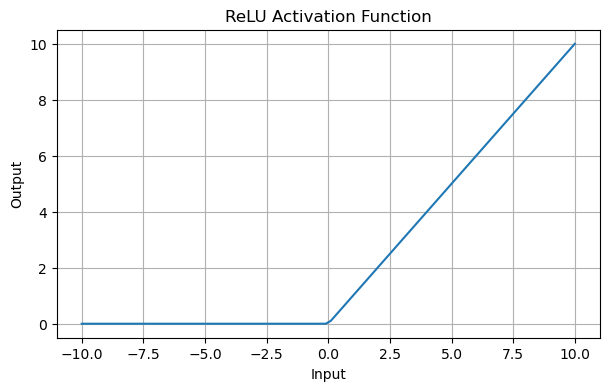

In [4]:
plt.figure(figsize=(7, 4))

plt.plot(x, relu(x))
plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.show()

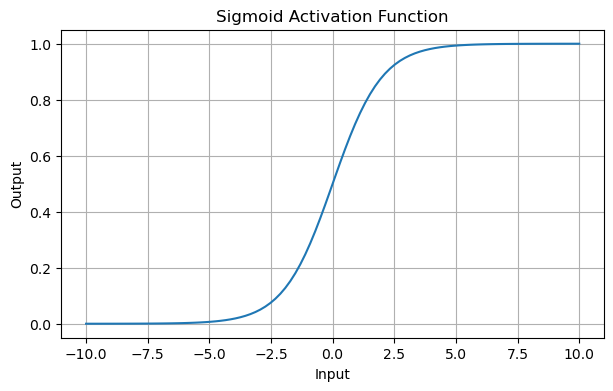

In [5]:
plt.figure(figsize=(7, 4))

plt.plot(x, sigmoid(x))
plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.show()

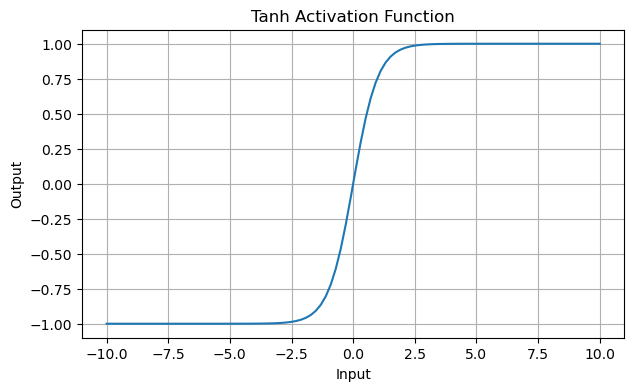

In [6]:
plt.figure(figsize=(7, 4))

plt.plot(x, tanh(x))
plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(True)

plt.show()

## Step 2: For the Phase 3 project task, decide the correct output activation and loss function, and justify both.



The heart disease prediction task is a **binary classification problem**, where the model predicts one of two possible classes: whether a person has heart disease or does not have heart disease.

For this reason, the **Sigmoid activation function** is used in the output layer. Sigmoid converts the network's output into a value between 0 and 1, which can be interpreted as the predicted probability of belonging to the positive class.

The **Binary Cross-Entropy loss function** is used because it is designed to measure the difference between the predicted probabilities and the actual binary labels.

Therefore, the network architecture will use:

* **ReLU** in the hidden layers to learn non-linear patterns.
* **Sigmoid** in the output layer to produce a probability between 0 and 1.
* **Binary Cross-Entropy** as the loss function to measure the prediction error.

--------------

## Step 3: By hand or in NumPy, compute one forward pass for a tiny 2-layer network on a sample input

In [16]:
# Select 10 real patients from the training data
samples = X_train_scaled[0:10]

# Network dimensions
n_features = X_train_scaled.shape[1]
n_hidden = 4

# Reproducibility
np.random.seed(42)

# -----------------------------
# Hidden Layer
# -----------------------------

# Randomly initialize weights and biases
W1 = np.random.randn(n_features, n_hidden)
b1 = np.zeros((1, n_hidden))

# Weighted sum
Z1 = np.dot(samples, W1) + b1

# Apply ReLU activation
A1 = relu(Z1)


# -----------------------------
# Output Layer
# -----------------------------

W2 = np.random.randn(n_hidden, 1)
b2 = np.zeros((1, 1))

# Weighted sum
Z2 = np.dot(A1, W2) + b2

# Apply Sigmoid activation
probabilities = sigmoid(Z2)


# -----------------------------
# Convert probabilities to classes
# -----------------------------

predictions = (probabilities >= 0.5).astype(int)


# -----------------------------
# Display Results
# -----------------------------

results = pd.DataFrame({
    "Probability": probabilities.flatten(),
    "Predicted Class": predictions.flatten()
})

print("Input shape:", samples.shape)

print("\nHidden Layer Output (After ReLU):")
print(A1)

print("\nFinal Prediction Probabilities (After Sigmoid):")
print(probabilities)

print("\nPredicted Classes:")
print(predictions)

print("\nResults:")
print(results)

Input shape: (10, 23)

Hidden Layer Output (After ReLU):
[[ 2.14574848  0.22438976  1.18108975  0.        ]
 [ 0.          0.          0.42413871  0.        ]
 [ 2.58994981  6.96099316  0.         10.88162988]
 [ 4.12725426  0.63386045  0.          5.14311212]
 [ 0.          0.31514974  3.63508361  7.50147017]
 [ 1.76361369  0.          0.          0.        ]
 [ 0.          0.          4.6710907   0.        ]
 [ 0.99303348  0.          0.          0.        ]
 [ 1.50343114  0.66837259  0.          0.        ]
 [ 0.92307281  0.          0.          0.        ]]

Final Prediction Probabilities (After Sigmoid):
[[1.14754666e-01]
 [4.58518504e-01]
 [2.01113976e-09]
 [2.41243395e-05]
 [3.70019145e-06]
 [2.24758092e-01]
 [1.38051021e-01]
 [3.32441699e-01]
 [2.18489798e-01]
 [3.43429975e-01]]

Predicted Classes:
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]

Results:
    Probability  Predicted Class
0  1.147547e-01                0
1  4.585185e-01                0
2  2.011140e-09       

## Step 4: Document the choices and the forward-pass result in Markdown

### Forward Propagation Using the Heart Disease Dataset

For this demonstration, **10 patient samples** were selected from the training data of the `heart_2020_raw.csv` dataset. Each patient was represented by **23 input features** after preprocessing and encoding.

The task is a **binary classification problem**, where the model predicts whether a patient has heart disease (`1`) or does not have heart disease (`0`). Therefore, **ReLU** was selected as the activation function for the hidden layer, while **Sigmoid** was selected for the output layer because it produces a probability between 0 and 1.

1. The forward propagation process began by passing the 10 input samples into a hidden layer, where the weighted sum was calculated using:

$$
Z_1 = XW_1 + b_1
$$

2. The ReLU activation function was then applied:

$$
A_1 = \text{ReLU}(Z_1)
$$

3. The resulting activated values were passed to the output layer:

$$
Z_2 = A_1W_2+b_2
$$

4. Finally, the Sigmoid activation function was applied:

$$
\hat{y} = \sigma(Z_2)
$$

This produced a probability for each of the 10 patients. A threshold of `0.5` was then used to convert each probability into a predicted class:

$$
\text{Predicted Class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \
0, & \text{if } \hat{y} < 0.5
\end{cases}
$$

### Results

| Patient | Predicted Probability | Predicted Class |
| ------- | --------------------: | --------------: |
| 1       |                0.1148 |               0 |
| 2       |                0.4585 |               0 |
| 3       |                0.0000 |               0 |
| 4       |                0.0000 |               0 |
| 5       |                0.0000 |               0 |
| 6       |                0.2248 |               0 |
| 7       |                0.1381 |               0 |
| 8       |                0.3324 |               0 |
| 9       |                0.2185 |               0 |
| 10      |                0.3434 |               0 |

All 10 samples received probabilities below the `0.5` threshold and were therefore assigned to class `0`, representing **no heart disease**.

However, these results should **not be interpreted as actual predictions about the patients**. The weights used in this manual demonstration were randomly initialized and have not been trained or updated through backpropagation.

Therefore, the purpose of this experiment is to demonstrate the mechanics of **forward propagation**:

$$
\text{10 Patient Inputs}
\rightarrow
\text{Weighted Sum}
\rightarrow
\text{ReLU}
\rightarrow
\text{Weighted Sum}
\rightarrow
\text{Sigmoid}
\rightarrow
\text{Probability}
\rightarrow
\text{Threshold}
\rightarrow
\text{Predicted Class}
$$

A trained neural network would repeatedly perform this process, calculate the loss, and use backpropagation to update its weights so that its predictions gradually become more meaningful.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">